In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import scipy.stats
from scipy.stats import rankdata

Text(0, 0.5, 'q_1b')

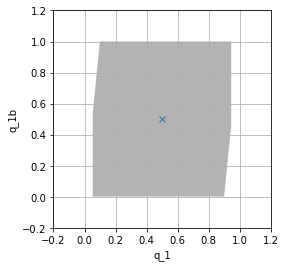

In [3]:
d = np.linspace(-0.2,1.2,500)
x,y = np.meshgrid(d,d)
plt.imshow( ((x>=0) & (y>=0) & (x<=1) & (y<=1) & (y<= x*10) & (y>= x*10-9) & ((x-1/2)**2<= 0.2)).astype(int) , 
                extent=(x.min(),x.max(),y.min(),y.max()),origin="lower", cmap="Greys", alpha = 0.3);
plt.plot(0.5,0.5,'x')
#plt.plot(0.5+np.zeros(50), np.linspace(-0.2,1.2,50),'--', color = 'r')
plt.grid()
plt.xlabel('q_1')
plt.ylabel('q_1b')

Text(0, 0.5, 'q_1b')

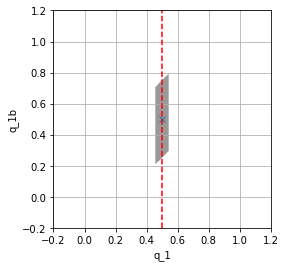

In [26]:
d = np.linspace(-0.2,1.2,1000)
x,y = np.meshgrid(d,d)
phi_dot = 2
N = 500
r = phi_dot/(2*N)*scipy.stats.chi2.ppf(0.95, 1)
plt.imshow( ((x>=0) & (y>=0) & (x<=1) & (y<=1) & (y<= 1-(1-x)**2) & (1-y<= 1-x**2) & ((x-1/2)**2<= r/4)).astype(int) , 
                extent=(x.min(),x.max(),y.min(),y.max()),origin="lower", cmap="Greys", alpha = 0.4);
#plt.plot(np.linspace(0,1,50),np.linspace(0,1,50))
plt.plot(0.5,0.5,'x')
plt.plot(0.5+np.zeros(50), np.linspace(-0.2,1.2,50),'--', color = 'r')
plt.grid()
plt.xlabel('q_1')
plt.ylabel('q_1b')
#plt.savefig('chi2spwN100.eps', format = 'eps')

In [52]:
r

1.920729410347062

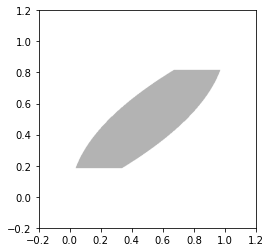

In [19]:
d = np.linspace(-0.2,1.2,500)
x,y = np.meshgrid(d,d)
plt.imshow( (((x>=0) & (y>=0) & (x<=1) & (y<=1) & (y<= 1-(1-x)**2) & (1-y<= 1-x**2) & ((x-1/2)**2<= 0.1)).T).astype(int), 
                extent=(x.min(),x.max(),y.min(),y.max()),origin="lower", cmap="Greys", alpha = 0.3);

#plt.grid()

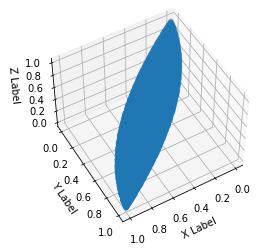

In [24]:
d = np.linspace(-0.2,1.2,200)
x,y = np.meshgrid(d,d)
data = ((x>=0) & (y>=0) & (x<=1) & (y<=1) & (y<= 1-(1-x)**2) & (1-y<= 1-x**2) & ((x-1/2)**2<= 0.5)).astype(int)
index = np.argwhere(data == 1)
x_ind = index[:,0]
y_ind = index[:,1]
a = x[0][x_ind]
b = y[:,0][y_ind]
z = 1-b
np.vstack((a,b)).T
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(a, b, z, marker='o')
ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')
ax.view_init(50, 60)

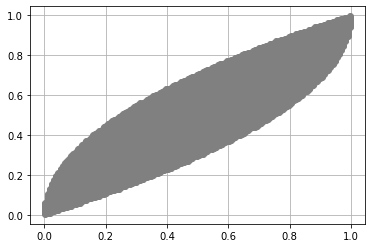

In [27]:
plt.plot(a,b,'o', color = 'grey')
plt.grid()

In [4]:
def meshgrid2(*arrs):
   ....:     arrs = tuple(reversed(arrs))
   ....:     lens = map(len, arrs)
   ....:     dim = len(arrs)
   ....:     sz = 1
   ....:     for s in lens:
   ....:        sz *= s
   ....:     ans = []
   ....:     for i, arr in enumerate(arrs):
   ....:         slc = [1]*dim
   ....:         slc[i] = lens[i]
   ....:         arr2 = asarray(arr).reshape(slc)
   ....:         for j, sz in enumerate(lens):
   ....:             if j != i:
   ....:                 arr2 = arr2.repeat(sz, axis=j)
   ....:         ans.append(arr2)
   ....:     return tuple(ans)

In [2]:
def h_spw(x,par):
    return(1-(1-x)**par)

def break_points(A):
    n = len(A)
    indices = []
    values = [] 
    val_pre = A[0]
    for i in range(n):
        if A[i] != val_pre:
            indices.append(i-1)
            val_pre = A[i]
            values.append(A[i-1])
    indices.append(n-1)
    values.append(A[n-1])
    return(np.array(indices),np.array(values))

def slice_ord_pos(A,value):
    n = len(A)
    for i in range(n):
        if A[i] > value:
            return(i-1)
        if i == n-1:
            return(n-1)

def slice_ord_neg(A,value):
    n = len(A)
    for i in range(n-1,-1,-1):
        if A[i] > value:
            return(n-i-2)
        if i == 0:
            return(n-1)

def check_constraints(q,q_bset,par):
    h_q1 = h_spw(q[0],par)
    h_q2 = h_spw(q[1],par)
    h_q1q2 = h_spw(q[0]+[1],par)
    h_q1m = h_spw(1-q[0],par)
    h_q2m = h_spw(1-q[1],par)
    h_q3 = h_spw(1-q[0]-q[1],par)
    indices, values = break_points(q_bset[:,0])
    ind_val1 = np.intersect1d(np.where(values<= h_q1),np.where(1-values <= h_q1m))
    ind_final = np.array([])
    for ind in ind_val1:
        if ind == 0:
            qb_test = q_bset[0:indices[ind]+1]
            i1 = slice_ord_pos(qb_test[:,1],h_q2)
            i2 = slice_ord_neg(1-qb_test[:,1],h_q2m)
            ind_test = np.intersect1d(np.arange(0,i1+1),np.arange(indices[ind],indices[ind]-i2-1,-1))
            ind_final = np.concatenate([ind_final, ind_test])
        else:
            qb_test = q_bset[indices[ind-1]+1:indices[ind]+1]
            i1 = slice_ord_pos(qb_test[:,1],h_q2)
            i2 = slice_ord_neg(1-qb_test[:,1],h_q2m)
            l = indices[ind-1]+1
            r = indices[ind]
            ind_test = np.intersect1d(np.arange(l,l+i1+1),np.arange(r,r-i2-1,-1))
            ind_final = np.concatenate([ind_final, ind_test])
    return(ind_final)
            
            
def check_constraints_brute(q,q_bset,par):
    h_q1 = h_spw(q[0],par)
    h_q2 = h_spw(q[1],par)
    h_q1q2 = h_spw(q[0]+q[1],par)
    h_q1m = h_spw(1-q[0],par)
    h_q2m = h_spw(1-q[1],par)
    h_q3 = h_spw(1-q[0]-q[1],par)
    constraints = (q_bset[:,0]<= h_q1)& (1-q_bset[:,0]<= h_q1m) &(q_bset[:,1]<= h_q2) & (1-q_bset[:,1]<= h_q2m)\
            & (q_bset[:,0] + q_bset[:,1] <= h_q1q2) & (1-q_bset[:,0]-q_bset[:,1] <= h_q3)
    return(np.where(constraints==True))
    

    

In [45]:
import itertools as itertools
phi_dot = 2
N = 500
r = phi_dot/(2*N)*scipy.stats.chi2.ppf(0.95, 2)
par = 2
q_set = np.asarray(list((itertools.product(np.linspace(0.001,1,250), repeat = 2))))
q_bset = q_set
q_set = q_set[(q_set[:,0] + q_set[:,1])<=1]
q_bset = q_set
#index = (q_set[:,0]*np.log(3*q_set[:,0])+q_set[:,1]*np.log(3*q_set[:,1])\
             #+(1-q_set[:,0]-q_set[:,1])*np.log(3*(1-q_set[:,0]-q_set[:,1])))<=r
index = ((q_set[:,0]-1/3)**2+(q_set[:,1]-1/3)**2+(1-q_set[:,0]-q_set[:,1]-1/3)**2)<=r/3
#index = (np.abs(q_set[:,0]-1/3)+np.abs(q_set[:,1]-1/3)+np.abs(1-q_set[:,0]-q_set[:,1]-1/3))<=r
q_set = q_set[index]

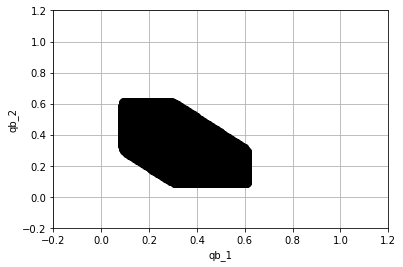

In [46]:
ind_qb = np.array([])
for q in q_set:
    new_ind = check_constraints_brute(q,q_bset,par)
    ind_qb = np.union1d(ind_qb, new_ind).astype(int)
q_bset1 = q_bset[ind_qb]
plt.xlim(-0.2,1.2)
plt.ylim(-0.2,1.2)
plt.xlabel('qb_1')
plt.ylabel('qb_2')
plt.plot(q_bset1[:,0], q_bset1[:,1], 'o', color = 'black')
plt.grid()
plt.savefig('N500qb_set.eps', format = 'eps')

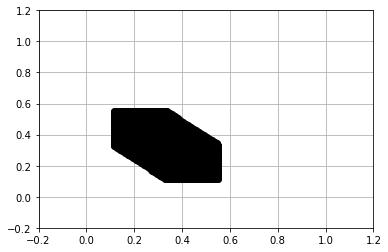

In [36]:
new_indp = check_constraints_brute(np.array([1/3,1/3]),q_bset,par)
new_indp = np.union1d(np.array([]), new_indp).astype(int)
qb_p = q_bset[new_indp]
plt.xlim(-0.2,1.2)
plt.ylim(-0.2,1.2)
plt.plot(qb_p[:,0], qb_p[:,1], 'o', color = 'black')
plt.grid()
plt.savefig('Ninfqb_set.eps', format = 'eps')